In [1]:
#импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import euclidean

# Загрузка данных
df = pd.read_csv("AB_NYC_2019.csv")

In [2]:
print(df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


In [3]:
#предварительная обработка данных
#Удаление ненужных признаков
df.drop(['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1, inplace=True)

In [4]:
#Обработка пропущенных значений
# Замена пропущенных значений в 'reviews_per_month' на 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

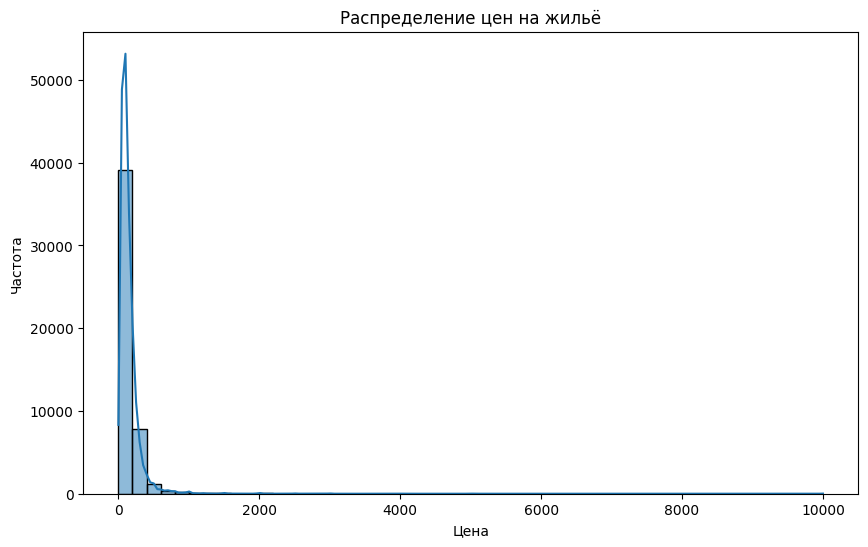

In [5]:
#визуализация данных
#Распределение цен
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Распределение цен на жильё')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

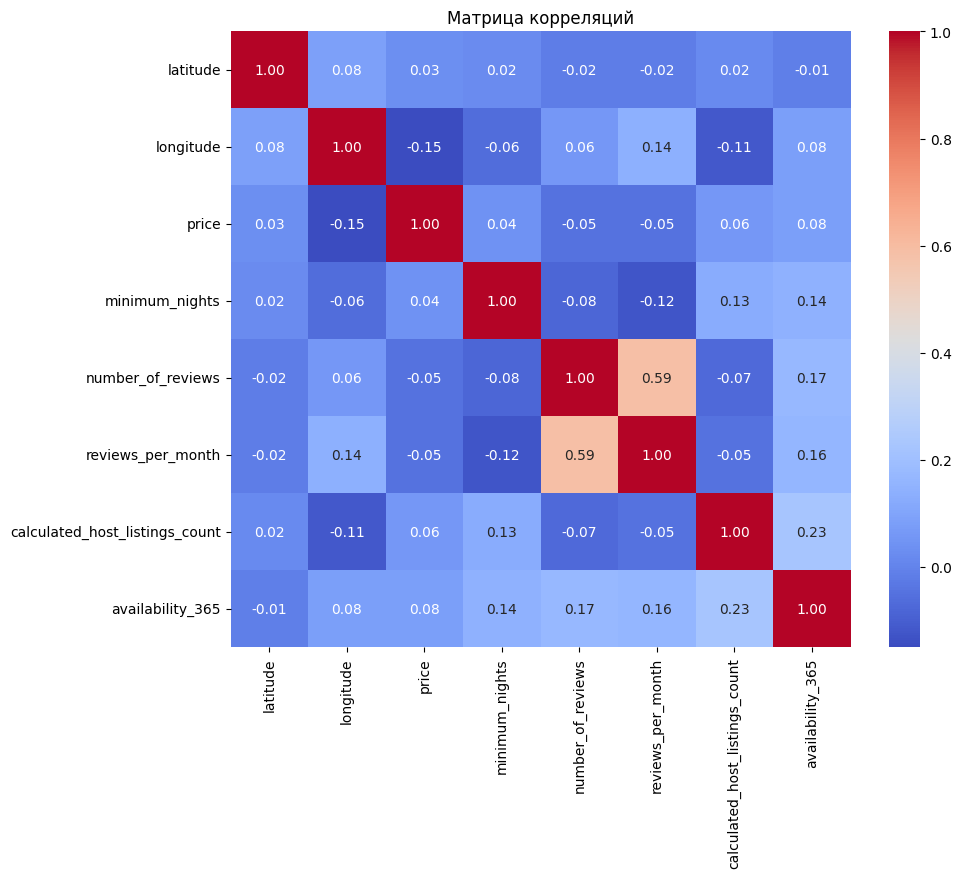

In [6]:
#Матрица корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

In [7]:
#Предобработка и генерация признаков
#Обработка аномалий
#Удаление выбросов в ценах
upper_limit = df['price'].quantile(0.99)
df = df[df['price'] <= upper_limit]

In [8]:
#Масштабирование данных и кодирование категориальных переменных
#Определение числовых и категориальных признаков
numeric_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
categorical_features = ['neighbourhood_group', 'neighbourhood', 'room_type']

In [9]:
#Создание трансформеров для числовых и категориальных данных
numeric_transformer = RobustScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [10]:
#Создание предобработчика с помощью ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [11]:
#Создание новых признаков
#Расчёт расстояния до центра Манхэттена
# Координаты центра Манхэттена
manhattan_center = (40.7580, -73.9855)

# Функция для вычисления евклидова расстояния
def calculate_distance(lat, lon, center):
    return euclidean((lat, lon), center)

# Применение функции к данным
df['distance_to_manhattan'] = df.apply(lambda row: calculate_distance(row['latitude'], row['longitude'], manhattan_center), axis=1)

# Добавление нового признака к числовым
numeric_features.append('distance_to_manhattan')

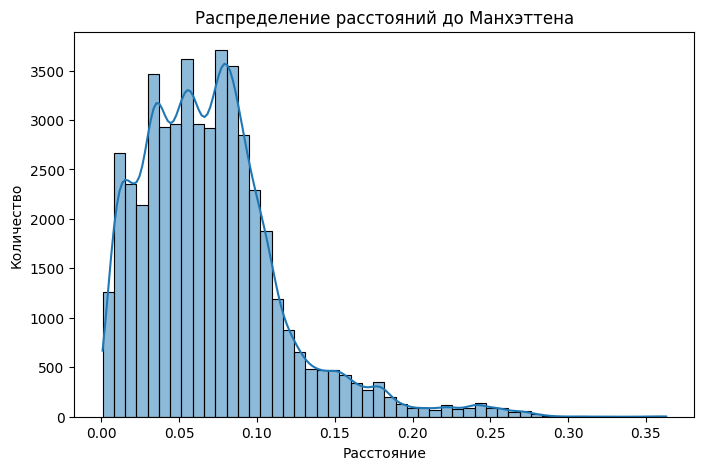

In [12]:
#Нарисуем график с новым признаком
plt.figure(figsize=(8, 5))
sns.histplot(df['distance_to_manhattan'], bins=50, kde=True)
plt.title('Распределение расстояний до Манхэттена')
plt.xlabel('Расстояние')
plt.ylabel('Количество')
plt.show()

In [13]:
#Проверка корреляции
correlation = df[['price', 'distance_to_manhattan']].corr()
print(correlation)

                          price  distance_to_manhattan
price                  1.000000              -0.335281
distance_to_manhattan -0.335281               1.000000


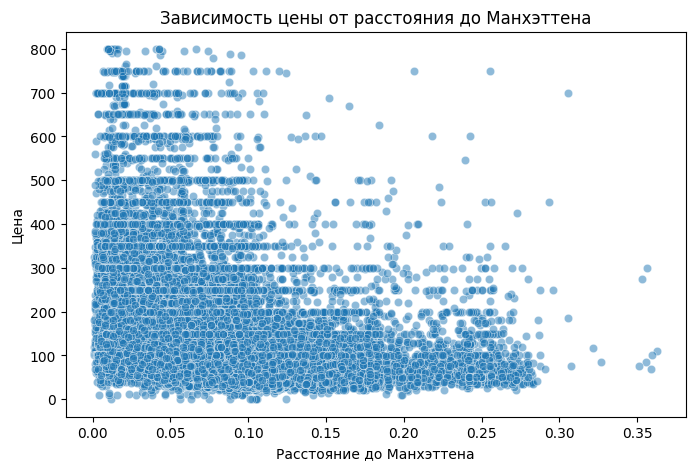

In [14]:
#Влияние цены
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['distance_to_manhattan'], y=df['price'], alpha=0.5)
plt.title('Зависимость цены от расстояния до Манхэттена')
plt.xlabel('Расстояние до Манхэттена')
plt.ylabel('Цена')
plt.show()

In [15]:
#Моделирование
#Разделение данных на обучающую и тестовую выборки
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Linear Regression:
R²: 0.4016
MAE: 49.89
RMSE: 80.39
------------------------------


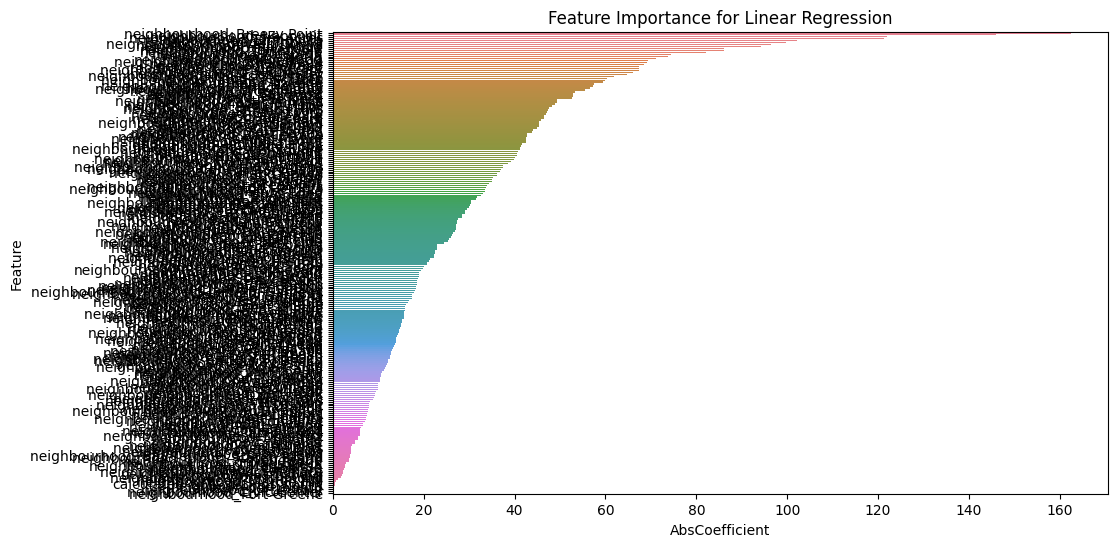

Ridge Regression:
R²: 0.4029
MAE: 49.80
RMSE: 80.30
------------------------------


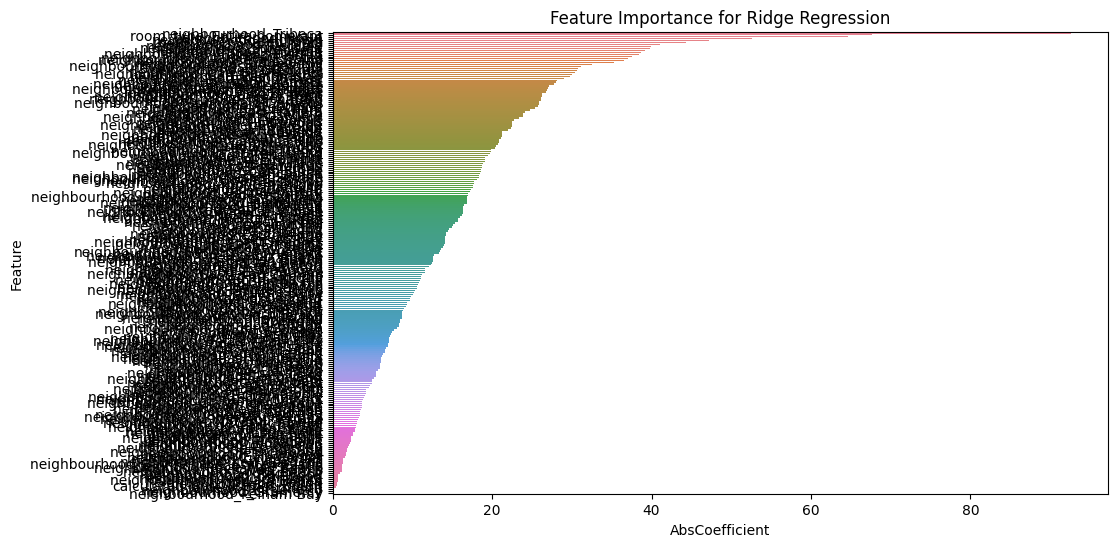

C:\Users\d.danchenko\PycharmProjects\otus\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 38442541.02686402, tolerance: 28986.758818122813
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\d.danchenko\PycharmProjects\otus\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 16447658.214715868, tolerance: 28986.758818122813
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\d.danchenko\PycharmProjects\otus\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 29257439.17122291, tolerance: 28986.758818122813
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\d.danc

Lasso Regression:
R²: 0.4022
MAE: 49.84
RMSE: 80.34
------------------------------


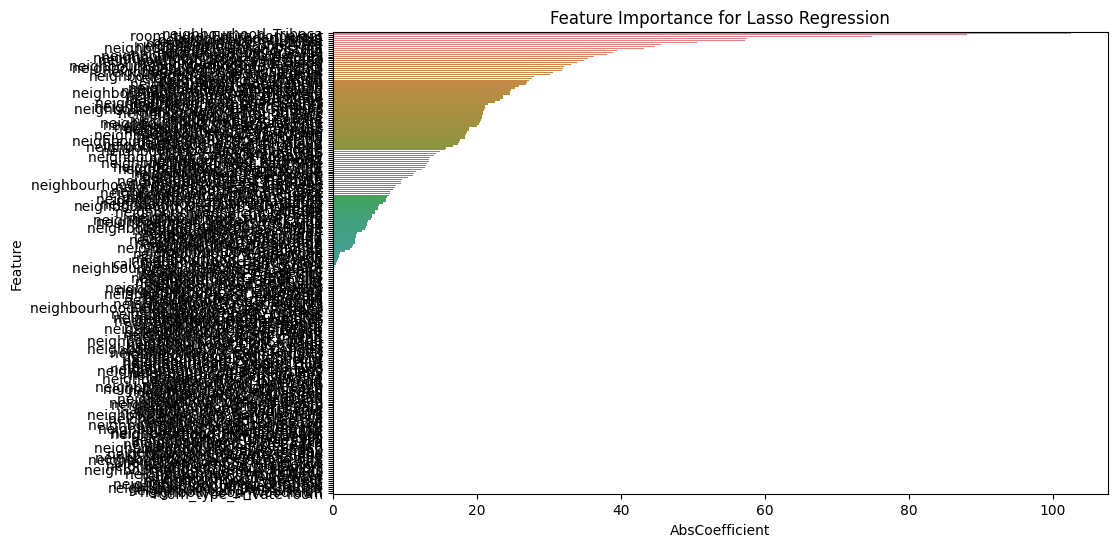

C:\Users\d.danchenko\PycharmProjects\otus\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 71370176.92254277, tolerance: 28986.758818122813
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\d.danchenko\PycharmProjects\otus\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 82031761.71587472, tolerance: 28986.758818122813
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\d.danchenko\PycharmProjects\otus\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 84122119.47316258, tolerance: 28986.758818122813
  model = cd_fast.sparse_enet_coordinate_descent(
C:\Users\d.danch

ElasticNet Regression:
R²: 0.4028
MAE: 49.80
RMSE: 80.30
------------------------------


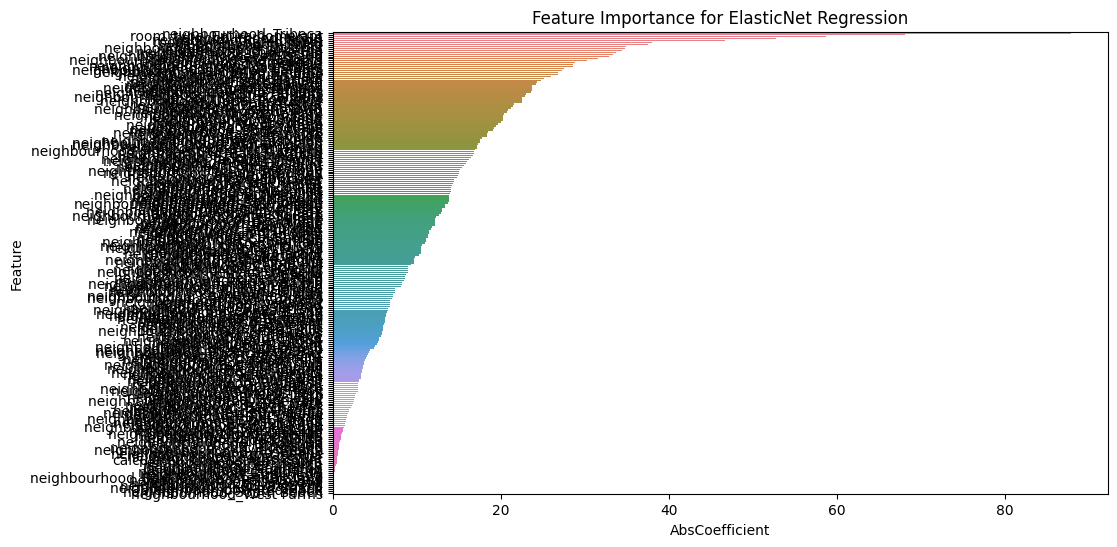

In [17]:
#Обучение моделей
# Определяем обработчики для числовых и категориальных признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Заполнение NaN средним
    ('scaler', StandardScaler())  # Стандартизация
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Заполнение NaN самым частым значением
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Кодирование категорий
])

# Применяем обработчики
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),  # Для числовых признаков
        ('cat', categorical_transformer, categorical_features)  # Для категориальных признаков
    ]
)

# Модели для обучения
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-6, 6, 13)),
    'Lasso Regression': LassoCV(alphas=np.logspace(-6, 6, 13)),
    'ElasticNet Regression': ElasticNetCV(alphas=np.logspace(-6, 6, 13))
}

# Функция для визуализации важности признаков
def plot_feature_importance(model, X_train, numeric_feature_names, categorical_feature_names, model_name):
    # Получаем коэффициенты модели
    if hasattr(model, 'coef_'):
        coef = model.coef_
    else:
        coef = np.zeros(X_train.shape[1])  # Если модель не имеет коэффициентов, возвращаем нули

    # Получаем имена признаков после one-hot кодирования
    onehot_feature_names = list(preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_feature_names))

    # Объединяем имена числовых и категориальных признаков
    all_feature_names = numeric_feature_names + onehot_feature_names
    
    # Создаем DataFrame для удобной визуализации
    coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coef})
    
    # Сортируем по абсолютной величине коэффициентов
    coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)
    
    # Визуализируем
    plt.figure(figsize=(10, 6))
    sns.barplot(x='AbsCoefficient', y='Feature', data=coef_df, hue='Feature', dodge=False)
    plt.title(f'Feature Importance for {model_name}')
    plt.show()

# Обучение моделей, оценка и визуализация важности признаков
for name, model in models.items():
    # Формируем пайплайн с обработчиком данных и моделью
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    
    # Обучение модели
    pipeline.fit(X_train, y_train)
    
    # Предсказания
    y_pred = pipeline.predict(X_test)
    
    # Оценка качества модели
    print(f'{name}:')
    print(f'R²: {r2_score(y_test, y_pred):.4f}')
    print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
    
    # Для RMSE извлекаем корень из MSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f'RMSE: {rmse:.2f}')
    print('-' * 30)
    
    # Визуализируем важность признаков
    plot_feature_importance(pipeline.named_steps['regressor'], X_train, numeric_features, categorical_features, name)

Linear Regression:
R²: 0.4016
MAE: 49.89
RMSE: 80.39

Ridge Regression:
R²: 0.4029
MAE: 49.80
RMSE: 80.30

Lasso Regression:
R²: 0.4022
MAE: 49.84
RMSE: 80.34

ElasticNet Regression:
R²: 0.4028
MAE: 49.80
RMSE: 80.30

Сходство показателей: Все модели демонстрируют практически идентичные результаты, что может указывать на отсутствие значительных преимуществ одной модели над другой для данного набора данных.

Коэффициент детерминации (R²): Значения около 0.40 свидетельствуют о том, что модели объясняют примерно 40% дисперсии зависимой переменной. Это может указывать на наличие других факторов, не учтенных в модели, влияющих на зависимую переменную.

Ошибки (MAE и RMSE): Похожие значения этих метрик подтверждают схожую производительность моделей.